# Import Libaries

In [1]:
import numpy as np
import pandas as pd

# Importing Data

In [2]:
crop = pd.read_csv("data 2/Crop Recommendation dataset.csv")
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# Asq Six Question to yourself

In [3]:
crop.shape

(2200, 8)

In [4]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
crop.duplicated().sum()

np.int64(0)

In [7]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
crop['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

# Encoding

In [9]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}
crop['crop_num']=  crop['label'].map(crop_dict)

In [10]:
crop

,N,P,K,temperature,humidity,ph,rainfall,label,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1
...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,22
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,22
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,22
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,22


In [11]:
crop.drop(['label'],axis=1,inplace=True)
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


# Train Test Split

In [12]:
X = crop.drop(['crop_num'],axis=1)
y = crop['crop_num']

In [13]:
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [14]:
y

0        1
1        1
2        1
3        1
4        1
        ..
2195    22
2196    22
2197    22
2198    22
2199    22
Name: crop_num, Length: 2200, dtype: int64

In [15]:
y.shape

(2200,)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1656,17,16,14,16.396243,92.181519,6.625539,102.944161
752,37,79,19,27.543848,69.347863,7.143943,69.408782
892,7,73,25,27.521856,63.132153,7.288057,45.208411
1041,101,70,48,25.360592,75.031933,6.012697,116.553145
1179,0,17,30,35.474783,47.972305,6.279134,97.790725
...,...,...,...,...,...,...,...
1638,10,5,5,21.213070,91.353492,7.817846,112.983436
1095,108,94,47,27.359116,84.546250,6.387431,90.812505
1130,11,36,31,27.920633,51.779659,6.475449,100.258567
1294,11,124,204,13.429886,80.066340,6.361141,71.400430



# Scale the features using MinMaxScaler

In [19]:
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()

X_train = ms.fit_transform(X_train)
X_test = ms.transform(X_test)

In [20]:
X_train

array([[0.12142857, 0.07857143, 0.045     , ..., 0.9089898 , 0.48532225,
        0.29685161],
       [0.26428571, 0.52857143, 0.07      , ..., 0.64257946, 0.56594073,
        0.17630752],
       [0.05      , 0.48571429, 0.1       , ..., 0.57005802, 0.58835229,
        0.08931844],
       ...,
       [0.07857143, 0.22142857, 0.13      , ..., 0.43760347, 0.46198144,
        0.28719815],
       [0.07857143, 0.85      , 0.995     , ..., 0.76763665, 0.44420505,
        0.18346657],
       [0.22857143, 0.52142857, 0.085     , ..., 0.56099735, 0.54465022,
        0.11879596]], shape=(1760, 7))

# Training Models

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

# create instances of all models
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Bagging': BaggingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreeClassifier(),
}


for name, model in models.items():
    model.fit(X_train,y_train)
    ypred = model.predict(X_test)
    
    print(f"{name}  with accuracy : {accuracy_score(y_test,ypred)}")
    print("Confusion matrix : ",confusion_matrix(y_test,ypred))
    print("==========================================================")
    

Logistic Regression  with accuracy : 0.9181818181818182
Confusion matrix :  [[16  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 6  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 3  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  

Random Forest  with accuracy : 0.990909090909091
Confusion matrix :  [[17  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

Gradient Boosting  with accuracy : 0.9818181818181818
Confusion matrix :  [[15  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 

In [22]:
# finally selected randomforest model

rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
ypred = rfc.predict(X_test)
accuracy_score(y_test,ypred)

0.9954545454545455

In [23]:
# or gausianjb
gnb = GaussianNB()
gnb.fit(X_train,y_train)
ypred = gnb.predict(X_test)
accuracy_score(y_test,ypred)

0.9954545454545455

# Predictive System

In [24]:
def recommendation(N,P,k,temperature,humidity,ph,rainfal):
    features = np.array([[N,P,k,temperature,humidity,ph,rainfal]])
    transformed_features = ms.fit_transform(features)
    prediction = rfc.predict(transformed_features)
    print(prediction)
    return prediction[0] 

In [25]:
# new inputs


N = 40
P = 50
k = 50
temperature = 40.0
humidity = 20
ph = 100
rainfall = 100

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[20]
Kidneybeans is a best crop to be cultivated 


In [26]:
# new inputs 2


N = 100
P = 90
k = 100
temperature = 50.0
humidity = 90.0
ph = 100
rainfall = 202.0

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[20]
Kidneybeans is a best crop to be cultivated 


In [27]:
# new inputs 2
N = 10
P = 10
k = 10
temperature = 15.0
humidity = 80.0
ph = 4.5
rainfall = 10.0

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[20]
Kidneybeans is a best crop to be cultivated 


In [28]:
import pickle
pickle.dump(rfc,open('model.pkl','wb'))
pickle.dump(ms,open('minmaxscaler.pkl','wb'))


# Section 6: Advanced Predictive Analytics (Top 3 Recommendations & Explainable AI)

In this section, we extend the crop recommendation system to suggest the top 3 best crops based on output prediction probabilities. We also train and compare alternative models (SVM, Naive Bayes, and Gradient Boosting), plot performance metrics, and integrate Explainable AI (SHAP and LIME) to analyze feature contributions. This serves as a foundation for academic-grade agricultural research.


In [29]:

import numpy as np

# Function for Top 3 Crop Recommendation
def recommend_top_3_crops(N, P, K, temp, humidity, pH, rainfall, model_obj=rfc):
    features = np.array([[N, P, K, temp, humidity, pH, rainfall]])
    scaled_features = ms.transform(features)
    
    # Check if standard scaler exists in scope
    if 'sc' in globals():
        final_features = sc.transform(scaled_features)
    else:
        # Check standard scaler file
        import os
        import pickle
        if os.path.exists('standscaler.pkl'):
            sc_loaded = pickle.load(open('standscaler.pkl', 'rb'))
            final_features = sc_loaded.transform(scaled_features)
        else:
            final_features = scaled_features
        
    probs = model_obj.predict_proba(final_features)[0]
    top_3_indices = np.argsort(probs)[-3:][::-1]
    
    crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}
                 
    results = []
    print("\n--- Top 3 Crop Recommendations ---")
    for rank, idx in enumerate(top_3_indices, 1):
        class_id = model_obj.classes_[idx]
        prob = probs[idx]
        crop_name = crop_dict.get(class_id, "Unknown")
        results.append((crop_name, prob))
        print(f"Rank {rank}: {crop_name} ({prob*100:.2f}% match confidence)")
    return results

# Test prediction (Expected: Rice/Jute/Cotton or similar)
print("Testing recommendation for Rice-like conditions (N=90, P=42, K=43, Temp=20.87, Humid=82.00, pH=6.5, Rain=202.93):")
_ = recommend_top_3_crops(90, 42, 43, 20.87, 82.00, 6.5, 202.93)


Testing recommendation for Rice-like conditions (N=90, P=42, K=43, Temp=20.87, Humid=82.00, pH=6.5, Rain=202.93):

--- Top 3 Crop Recommendations ---
Rank 1: Apple (52.00% match confidence)
Rank 2: Grapes (13.00% match confidence)
Rank 3: Banana (13.00% match confidence)



## Multi-Model Comparison (Research Focus)
We compare our primary Random Forest model with Support Vector Machine (SVC), Gradient Boosting Classifier, and Naive Bayes models. We evaluate them on standard metrics: Accuracy, Precision, Recall, and F1-Score.


Training Support Vector Machine...
Training Gradient Boosting...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training Naive Bayes...

--- Model Performance Comparison ---
                 Model  Accuracy  Precision   Recall  F1-Score
         Random Forest  0.995455   0.995818 0.995455  0.995423
Support Vector Machine  0.968182   0.972955 0.968182  0.968246
     Gradient Boosting  0.981818   0.984271 0.981818  0.981851
           Naive Bayes  0.995455   0.995818 0.995455  0.995423


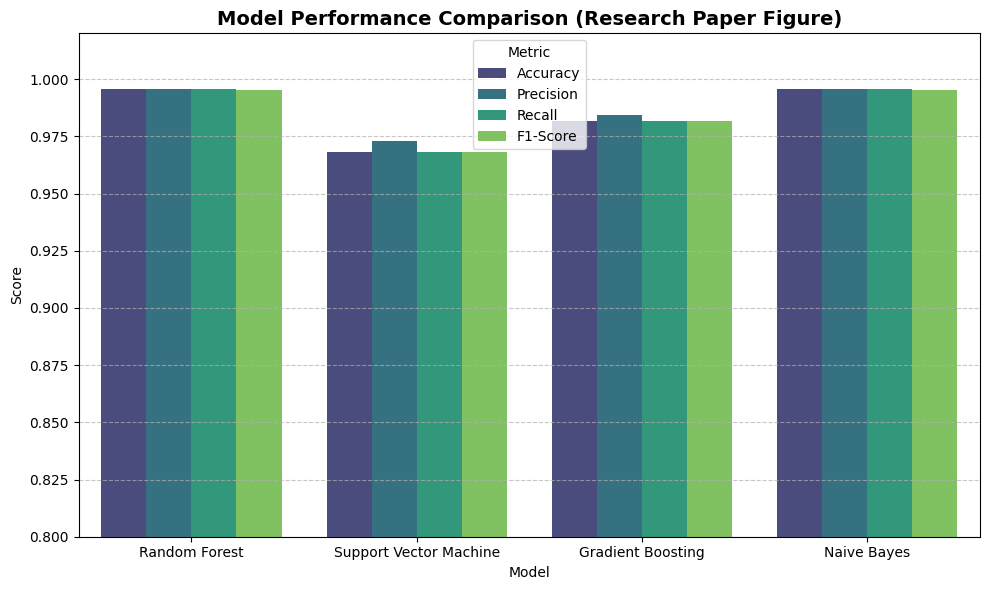

In [30]:

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define models
models = {
    "Random Forest": rfc,  # already trained
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

# Fit models (excluding RF which is already fit, or refitting to ensure consistency)
for name, clf in models.items():
    if name != "Random Forest":
        print(f"Training {name}...")
        clf.fit(X_train, y_train)

# Evaluate models
results_list = []
for name, clf in models.items():
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results_list)
print("\n--- Model Performance Comparison ---")
print(results_df.to_string(index=False))

# Plot comparative bar chart
plt.figure(figsize=(10, 6))
df_melted = pd.melt(results_df, id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(data=df_melted, x="Model", y="Value", hue="Metric", palette="viridis")
plt.title("Model Performance Comparison (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.02)
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()



## Confusion Matrix and ROC Curves
We plot the Confusion Matrix for the Random Forest model and multiclass ROC-AUC curves for a subset of representative crops to analyze classification performance and class-wise errors.


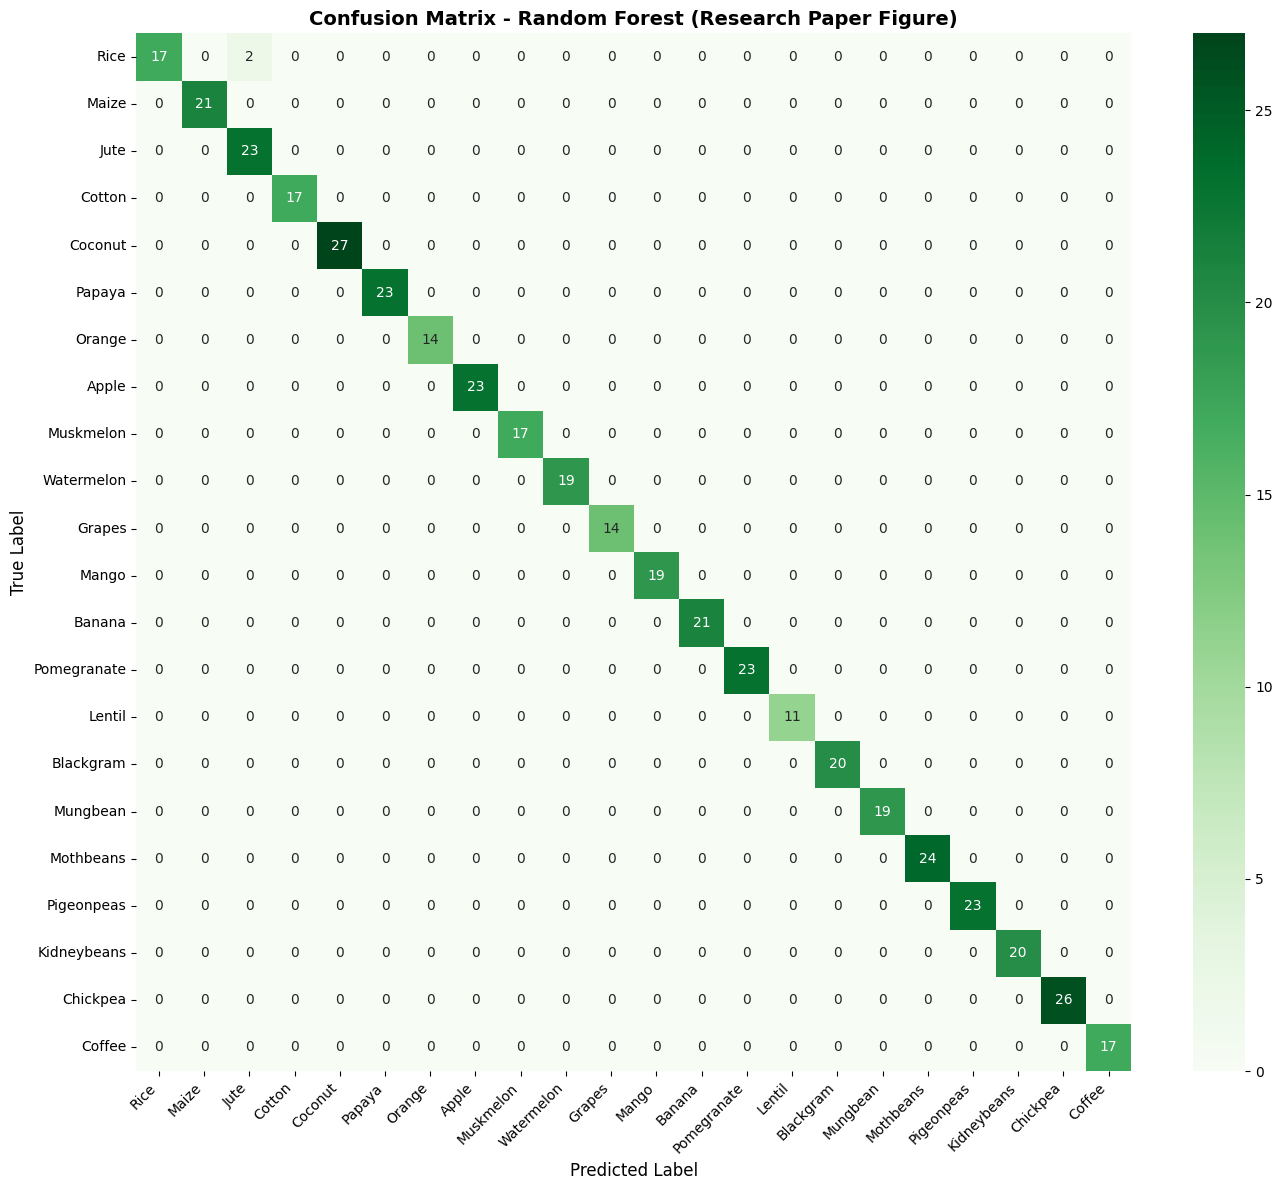

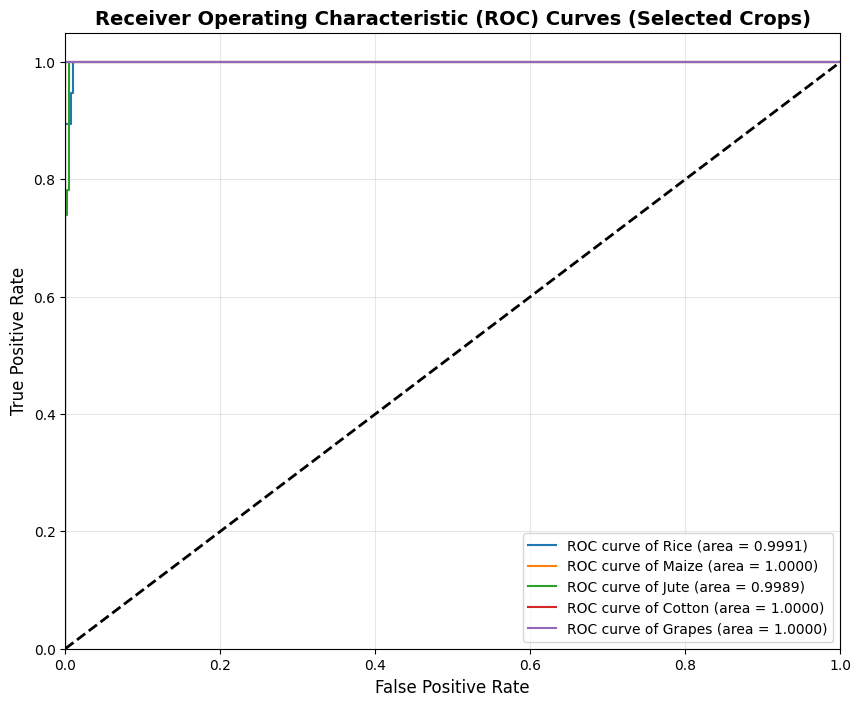

In [31]:

# Confusion Matrix for Random Forest
best_model_name = "Random Forest"
best_clf = models[best_model_name]
y_pred_best = best_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
             8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
             14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
             19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}
crop_names = [crop_dict.get(c, f"Class {c}") for c in best_clf.classes_]

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=crop_names, yticklabels=crop_names)
plt.title(f"Confusion Matrix - {best_model_name} (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# Multiclass ROC curves
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=best_clf.classes_)
n_classes = y_test_bin.shape[1]
y_score = best_clf.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for representative classes
selected_classes = [0, 1, 2, 3, 10]  # Rice, Maize, Jute, Cotton, Grapes
plt.figure(figsize=(10, 8))
for i in selected_classes:
    class_name = crop_names[i]
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of {class_name} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves (Selected Crops)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_curves.png", dpi=300)
plt.show()



## Explainable AI: SHAP (SHapley Additive exPlanations)
SHAP values provide a game-theoretic approach to explaining the contribution of each feature to predictions. We first compute global feature importance (SHAP summary plot) and then explain a specific individual prediction (SHAP local bar plot).



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/anandkumarmishra/Library/Python/3.12/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/anandkumarmishra/Library/Python/3.12/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/anandkumarmishra/Library/Python/3.12/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in

AttributeError: _ARRAY_API not found

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/z_/01d7knkd4bj7gscvx3qprvq80000gn/T/ipykernel_83715/1375809433.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


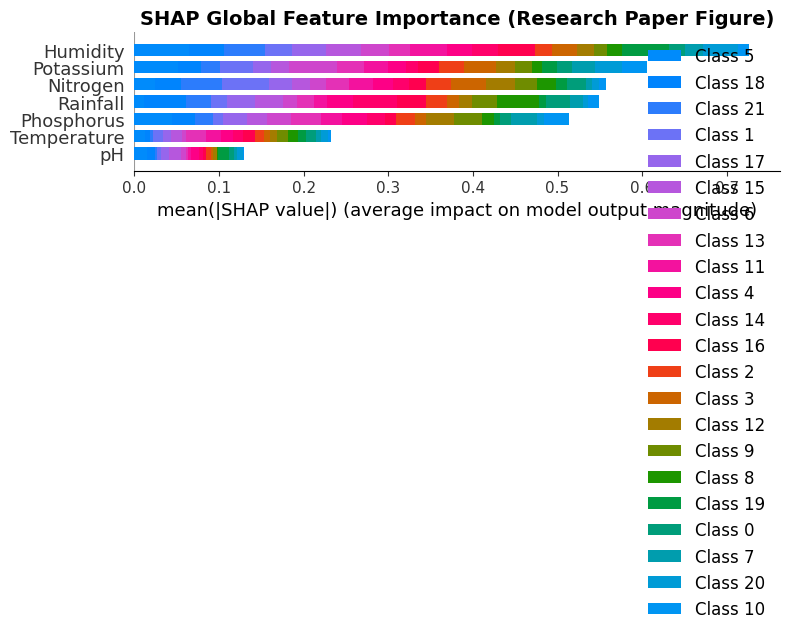

Explaining local prediction for sample 0 (Predicted Crop: Muskmelon)


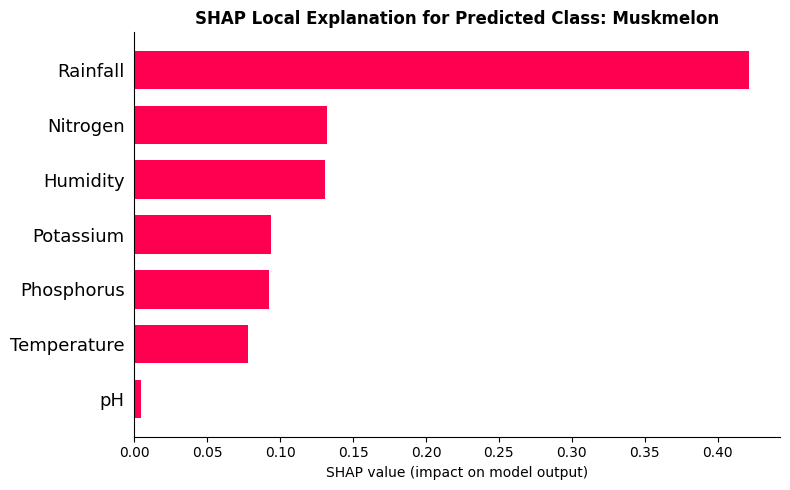

In [32]:

import shap

# Initialize SHAP TreeExplainer on Random Forest model
explainer = shap.TreeExplainer(best_clf)

# Calculate SHAP values on first 100 test samples to run quickly
shap_values = explainer.shap_values(X_test[:100])
feature_list = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH', 'Rainfall']

# Global SHAP Feature Importance Plot
plt.figure(figsize=(10, 6))
# For multiclass, shap_values is a list. summary_plot handles it directly.
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_list, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (Research Paper Figure)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=300)
plt.show()

# Local SHAP Explanation for the first test instance
test_idx = 0
sample = X_test[test_idx:test_idx+1]
predicted_class_id = best_clf.predict(sample)[0]
predicted_crop = crop_dict[predicted_class_id]
class_idx = list(best_clf.classes_).index(predicted_class_id)

print(f"Explaining local prediction for sample {test_idx} (Predicted Crop: {predicted_crop})")

plt.figure(figsize=(8, 5))
# Plot local SHAP bar plot for predicted class index
shap.bar_plot(shap_values[test_idx, :, class_idx], feature_names=feature_list, show=False)
plt.title(f"SHAP Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_local_explanation.png", dpi=300)
plt.show()



## Explainable AI: LIME (Local Interpretable Model-agnostic Explanations)
LIME builds a local surrogate linear model to explain individual predictions in a human-interpretable format. Unlike SHAP which explains the scaled features, we wrap our prediction pipeline to explain LIME on the **raw feature scales** (e.g. Nitrogen in mg/kg).


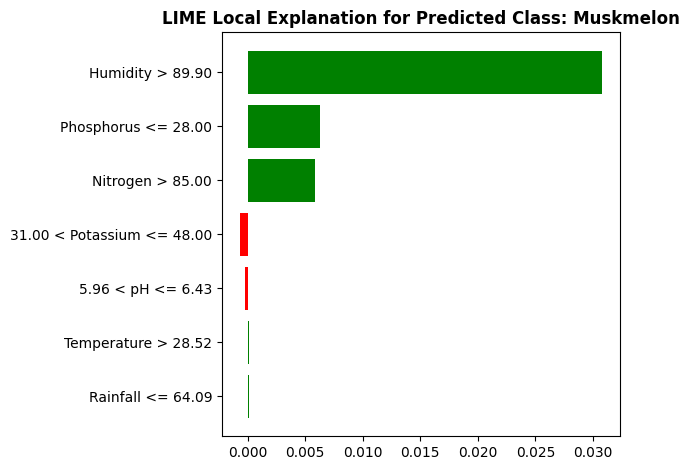

In [33]:

from lime import lime_tabular
from sklearn.model_selection import train_test_split

# Reload raw features to initialize LIME in original scales
df_raw = pd.read_csv('data 2/Crop Recommendation dataset.csv')
X_raw = df_raw.iloc[:, :-1].values
y_raw = df_raw.iloc[:, -1].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Predict function wrapper that handles scaling before prediction
def predict_fn(x_raw):
    if len(x_raw.shape) == 1:
        x_raw = x_raw.reshape(1, -1)
    scaled = ms.transform(x_raw)
    if 'sc' in globals():
        final = sc.transform(scaled)
    else:
        final = scaled
    return best_clf.predict_proba(final)

# Initialize LIME Tabular Explainer on RAW training data
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=feature_list,
    class_names=crop_names,
    mode='classification'
)

# Explain the first test instance (corresponds to test_idx=0)
exp = lime_explainer.explain_instance(
    data_row=X_test_raw[test_idx],
    predict_fn=predict_fn,
    num_features=7,
    labels=[class_idx]
)

# Plot LIME explanation for the predicted class
fig = exp.as_pyplot_figure(label=class_idx)
plt.title(f"LIME Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("lime_local_explanation.png", dpi=300)
plt.show()
